# Validation of branch *mappedDistortion*

In [32]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# To interact with the plot use
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from mpl_interactions import ipyplot as iplt
from prettytable import PrettyTable

# PlatoSim
import platosim.referenceFrames as rf
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook()

## Test case using mapped PSF

In [74]:
# Inputs
inputDir    = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
inputFile   = inputDir + "/inputfile.yaml"

# Outputs
outputDir      = os.getcwd()
outputFileName = "output_example1"

# Set up a Simulation object
sim = Simulation(outputFileName, inputFile, outputDir=outputDir)

# Subfield
sim["SubField/ZeroPointRow"]    = 2000
sim["SubField/ZeroPointColumn"] = 2000
sim["SubField/NumColumns"]      = 8
sim["SubField/NumRows"]         = 8

# PSF - SELECT:
sim["PSF/Model"] = "MappedFromFile"
# sim["PSF/Model"] = "AnalyticNonGaussian"

# Automatic catalogue file creation
row = np.array([3.5]) + sim["SubField/ZeroPointRow"]
col = np.array([3.5]) + sim["SubField/ZeroPointColumn"]
mag = np.array([10.0])
ID  = [0]
starcatFile = outputDir + "/starcat_example1.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
sim["ObservingParameters/StarCatalogFile"] = starcatFile

# Run simulation
simfile = sim.run(removeOutputFile=True)


2023-01-09 10:35:48 WARNING Simulation: no information about detected stars to write to HDF5
2023-01-09 10:35:48 WARNING Camera: No star positions to write to HDF5 file.



<IPython.core.display.Javascript object>


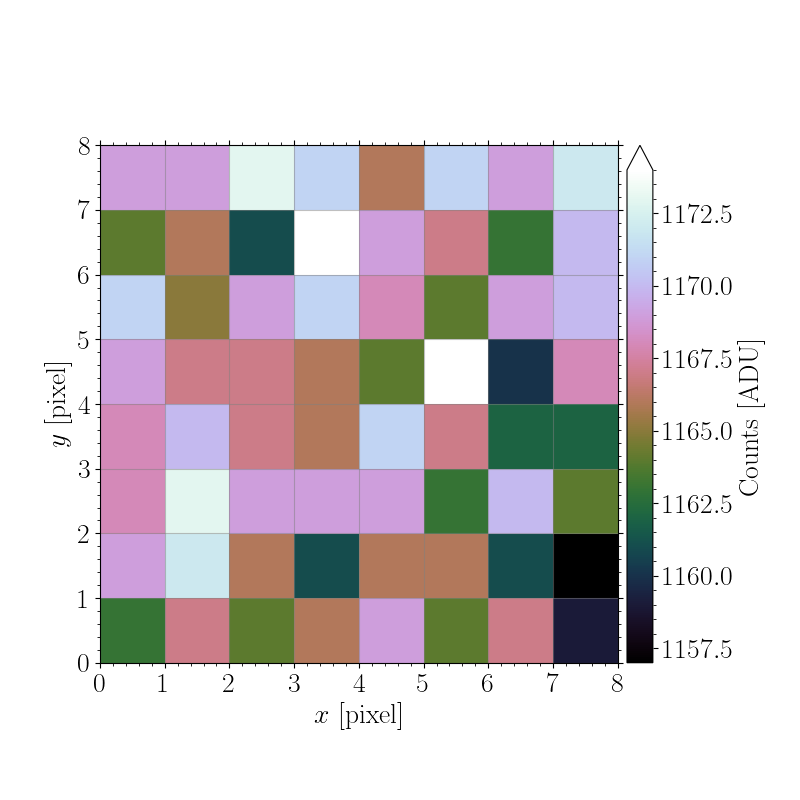

interactive(children=(IntSlider(value=0, description='Image:', layout=Layout(width='70%'), max=9), Output()), …

In [75]:
fig, ax = simfile.showImage(clipPercentile=1, imgScale="clip", fontSize=20, 
                            colorMap="cubehelix", colorBar=True, showGrid=True);

In [ ]:
# # Matrix to calculate the PSFs
# alpha = [14.6, 14.7, 15.2, 15.9, 16.8, 17.9, 19.2, 20.6,
#          12.5, 12.7, 13.2, 14.0, 15.0, 16.3, 17.7, 19.2,
#          10.4, 10.6, 11.2, 12.1, 13.3, 14.7, 16.3, 17.9,
#           8.3,  8.6,  9.3, 10.4, 11.8, 13.3, 15.0, 16.8,
#           6.2,  6.6,  7.5,  8.8, 10.4, 12.1, 14.0, 15.9,
#           4.2,  4.7,  5.9,  7.5,  9.3, 11.2, 13.2, 15.2, 
#           2.1,  2.9,  4.7,  6.6,  8.6, 10.6, 12.7, 14.7,
#           0.0,  2.1,  4.2,  6.2,  8.3, 10.4, 12.5, 14.6]
# inrot = [90.0, 81.9, 74.1, 66.8, 60.3, 54.5, 49.4, 45.0,
#          90.0, 80.5, 71.6, 63.4, 56.3, 50.2, 45.0, 40.6,
#          90.0, 78.7, 68.2, 59.0, 51.3, 45.0, 39.8, 35.5,
#          90.0, 76.0, 63.4, 53.1, 45.0, 38.7, 33.7, 29.7,
#          90.0, 71.6, 56.3, 45.0, 36.9, 31.0, 26.6, 23.2,
#          90.0, 63.4, 45.0, 33.7, 26.6, 21.8, 18.4, 15.9,
#          90.0, 45.0, 26.0, 18.4, 14.0, 11.3,  9.5,  8.1,
#           0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0, 0.0]
# n = len(alpha)

In [ ]:
# # Loop over each simulation
# for i in tqdm(range(n), bar_format=ut.tqdm_bar_format()):

#     # Select values
#     alpha_i = alpha[i]
#     inrot_i = inrot[i]
    
#     # Initialise PlatoSim
#     outputFileName = ("output_ZemaxPSF_num" + f"{i}".zfill(2) + "_alpha{:.1f}_inrot{:.1f}".format(alpha_i, inrot_i))
#     sim = Simulation(outputFileName, outputDir=os.getcwd())

#     # From alpha to focal plane coordinates
#     focalLength = sim["Camera/FocalLength/ConstantValue"] * 1000
#     xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(alpha_i), focalLength, 
#                                                                   inPlaneRotation=np.deg2rad(inrot_i))

#     # From focal plane coordinates to CCD coordinates
#     pixelSize  = sim["CCD/PixelSize"]
#     xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, pixelSize, 
#                                                  ccdZeroPointX=0, ccdZeroPointY=0, CCDangle=0)

#     # Observation
#     sim["ObservingParameters/NumExposures"] = 1

#     # Subfield (note y here is row and x is column)
#     xzero = sim["SubField/ZeroPointRow"]    = int(yCCD)
#     yzero = sim["SubField/ZeroPointColumn"] = int(xCCD)
#     xsub  = sim["SubField/NumColumns"]      = 8
#     ysub  = sim["SubField/NumRows"]         = 8

#     # Camera
#     sim["Camera/IncludePointLikeGhosts"] = False
    
#     # PSF
#     sim["PSF/Model"] = "MappedFromFile"
#     sim["PSF/MappedFromFile/IncludeChargeDiffusion"] = True

#     # Control HDF5
#     sim["ControlHDF5Content/WriteStarPositions"]     = True
#     sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
#     sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

#     # Create star catalogue (path to starcat is automatically by function)
#     xpos = np.array([int(xsub/2.) + xzero])
#     ypos = np.array([int(ysub/2.) + yzero])
#     mag  = np.array([10.0])
#     ID   = np.array([1])
#     starcat = f"{os.getcwd()}/starcat.txt"
#     sim.createStarCatalogFileFromPixelCoordinates(xpos, ypos, mag, ID, starcat)

#     # Run simulation
#     sim.run(removeOutputFile=True)